# Lista 4 - KONWOLUCJE

In [1]:
import numpy as np
import torch
from scipy.signal import convolve2d
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchinfo import summary
from numpy.lib.stride_tricks import sliding_window_view

## Zad1:

### Na początek stwórzmy funkcję, do przeprowadzania konwolucji  filtrem K na obrazie X:
Zamiast robić konwolucje pętlą, możemy wykorzystać operacje na macierzach, aby zoptymalizować działanie kodu. Dodatkowo wprowadzimy do funkcji możliwość ustawienia paddingu. Stride sztywno ustawiamy na 1

In [2]:
def convolution(X, K, q: int, padding: int = 0):
  '''
  Wykonuje operację konwolucji na wejściowym obrazie *X* oraz filtrze *K*. 
  Args:
    X: numpy / torch tensor o wymiarach (h, w, d)
    K: numpy / torch tensor o wymiarach (k_h, k_w, d, q)
    q: liczba filtrów
    padding: liczba pikseli paddingu dodawanych wokół obrazu (domyślnie 0)
  '''
  
  # Uwzględnimy oba przypadki - numpy i torch
  is_torch = isinstance(X, torch.Tensor)
  
  if padding > 0:
    if is_torch:
      X = F.pad(X.permute(2, 0, 1), (padding, padding, padding, padding), mode='constant', value=0).permute(1, 2, 0)
    else:
      X = np.pad(X, ((padding, padding), (padding, padding), (0, 0)), mode='constant', constant_values=0)
  
  h, w, d = X.shape
  k_h, k_w, _, _ = K.shape  

  # stride = 1
  h_out = h - k_h + 1
  w_out = w - k_w + 1
  
  if is_torch:
    # Przekształcamy X z (h, w, d) na (d, h, w) na potrzeby funkcji unfold
    X_permuted = X.permute(2, 0, 1).unsqueeze(0)  # (1, d, h, w)
    
    # patches ma kształt (1, d*k_h*k_w, h_out*w_out)
    patches = F.unfold(X_permuted, kernel_size=(k_h, k_w), stride=1)
    
    # Przekształcamy: (1, d*k_h*k_w, h_out*w_out) -> (d*k_h*k_w, h_out*w_out)
    patches = patches.squeeze(0) 
    
    # Zmieniamy kolejność, aby dostać (h_out*w_out, k_h*k_w*d)
    patches = patches.reshape(d, k_h * k_w, -1)  # (d, k_h*k_w, h_out*w_out)
    patches = patches.permute(2, 1, 0)  # (h_out*w_out, k_h*k_w, d)
    patches = patches.reshape(-1, k_h * k_w * d)  # (h_out*w_out, k_h*k_w*d)
    
    # Reshape filtra K z (k_h, k_w, d, q) na (k_h*k_w*d, q)
    K_reshaped = K.reshape(-1, q)
    
    # Mnożenie macierzowe
    output = torch.matmul(patches, K_reshaped)
    
    # Reshape do (h_out, w_out, q)
    output = output.reshape(h_out, w_out, q)
    
  else:
    # NumPy - używamy sliding_window_view
    patches = sliding_window_view(X, (k_h, k_w, d))
    
    # Reshape do (h_out, w_out, k_h*k_w*d)
    patches = patches.reshape(h_out, w_out, -1)
    
    # Reshape filtra K z (k_h, k_w, d, q) na (k_h*k_w*d, q)
    K_reshaped = K.reshape(-1, q)
    
    # Mnożenie macierzowe
    output = np.dot(patches, K_reshaped)
  
  return output

### Przypadki testowe

In [3]:
def generate_deterministic_tensor(shape, mod_val=5, offset=0):
    count = 1
    for s in shape:
        count *= s
    # Tworzymy sekwencję 0, 1, 2... i bierzemy modulo
    data = torch.arange(count).float() % mod_val + offset
    return data.reshape(shape)

def torch_2_numpy(pt):
  return pt.detach().numpy()

def run_pytorch_test(case_name, img_hwc, kernel_hwcn):
    image_hwc = generate_deterministic_tensor(img_hwc, mod_val=5)
    kernel_hwcn = generate_deterministic_tensor(kernel_hwcn, mod_val=3, offset=-1)

    print(f"Input shape (H,W,C): {tuple(image_hwc.shape)}")
    print(f"Kernel shape (H,W,Cin,Cout): {tuple(kernel_hwcn.shape)}")

    # Dodanie wymiaru batcha
    input_tensor = image_hwc.permute(2, 0, 1).unsqueeze(0)
    weights = kernel_hwcn.permute(3, 2, 0, 1)
    output_tensor = F.conv2d(input_tensor, weights, stride=1, padding=0)
    output_hwc = output_tensor.squeeze(0).permute(1, 2, 0)

    # ODKOMENTUJ JEŚLI twoim inputem jest wielowymiarowa macierz NumPy
    # image_hwc = torch_2_numpy(image_hwc)
    # kernel_hwcn = torch_2_numpy(kernel_hwcn)

    my_output = convolution(image_hwc, kernel_hwcn, kernel_hwcn.shape[-1])
    if isinstance(my_output, np.ndarray):
        my_output = torch.from_numpy(my_output)

    my_output = my_output.to(torch.float64)
    output_hwc = output_hwc.to(torch.float64) # do samego typu żeby nie było błędu

    try:
      torch.testing.assert_close(my_output, output_hwc, rtol=1e-05, atol=1e-08)
      print(f"Test zaliczony")
    except AssertionError as e:
      print(f"Test niezaliczony: {e}")
    print(f"Output shape (H,W,C): {tuple(output_hwc.shape)}")

# --- URUCHOMIENIE PRZYPADKÓW ---

# Przypadek 1: Mały
run_pytorch_test("PRZYPADEK 1", (6, 6, 3), (3, 3, 3, 5))

# Przypadek 2: Średni
run_pytorch_test("PRZYPADEK 2", (12, 12, 3), (3, 3, 3, 5))

# Przypadek 3: Projekcja 1x1
run_pytorch_test("PRZYPADEK 3", (24, 24, 3), (1, 1, 3, 10))

Input shape (H,W,C): (6, 6, 3)
Kernel shape (H,W,Cin,Cout): (3, 3, 3, 5)
Test zaliczony
Output shape (H,W,C): (4, 4, 5)
Input shape (H,W,C): (12, 12, 3)
Kernel shape (H,W,Cin,Cout): (3, 3, 3, 5)
Test zaliczony
Output shape (H,W,C): (10, 10, 5)
Input shape (H,W,C): (24, 24, 3)
Kernel shape (H,W,Cin,Cout): (1, 1, 3, 10)
Test zaliczony
Output shape (H,W,C): (24, 24, 10)


Wszystko  śmiga

## Zad 2:

funkcja do sprawdzania:

In [4]:
def validate_layer(case_name, layer, input_shape, expected_shape):
    print(f"--- {case_name} ---")
    print(f"Input: {input_shape}")

    # Tworzymy losowy tensor z batch=1
    x = torch.randn(1, *input_shape)

    try:
        y = layer(x)
        out_shape = tuple(y.shape)[1:] # bez batch

        print(f"Oczekiwany kształt: {expected_shape}")
        print(f"Twój kształt:       {out_shape}")

        if out_shape == expected_shape:
            print("OK. \n")
        else:
            print("Błąd: Kształty się nie zgadzają.\n")

    except Exception as e:
        print(f"Jakiś błąd: {e}\n")

PRZYPADEK 1: Agresywna redukcja (styl pierwszej warstwy AlexNet)

Wejście: 224x224 (obraz)

Wyjście: 55x55

Wymagane: Użyj Padding=2. Resztę dobierz.

Wskazówka: Kernel jest duży (>7), a krok (stride) też jest spory (>2).

In [5]:
case_1 = nn.Conv2d(
    in_channels=3,
    out_channels=64,
    padding=2,
    dilation=1,
    # --- DO UZUPEŁNIENIA ---
    kernel_size=1,  # <-- zmień to
    stride=1        # <-- zmień to
)


No to tutaj musimy podłożyć do wzoru na W out:
$$55 = \left\lfloor \frac{224 + 2(2) - 1*(K-1)-1}{S} \right\rfloor + 1$$
Z czego otrzymujemy:
$$ K = 224 + 2*2 - S(55-1)  => K = 228 - 54S  $$

Teraz wystarczy podstawić jaką wartośc w miejsce K lub S i drugie się łatwo wyliczy.
Do takich par należą chociażby $$ K = 174 , S = 1$$ lub $$K = 66 , S = 3$$ No tu widzimy że im mniejszy stride, tym większy jest kernel a używanie tak dużego filtra nie wydaje się rozsądne, ale para$$ K = 12 , S = 4$$  już sens w miarę ma. 

In [6]:
case_1 = nn.Conv2d(
    in_channels=3,
    out_channels=64,
    padding=2,
    dilation=1,
    kernel_size=12,  
    stride=4       
)

Test 1

In [7]:

validate_layer("PRZYPADEK 1: Redukcja 224 -> 55", case_1,
                input_shape=(3, 224, 224),
                expected_shape=(64, 55, 55))

--- PRZYPADEK 1: Redukcja 224 -> 55 ---
Input: (3, 224, 224)
Oczekiwany kształt: (64, 55, 55)
Twój kształt:       (64, 55, 55)
OK. 



PRZYPADEK 2: Asymetryczna konwolucja

Wejście: 32x32

Wyjście: 30x16

Wymagane: Padding=0.

Wskazówka: Wysokość (32->30) maleje wolno, Szerokość (32->16) maleje szybko.

Użyj krotki (tuple) dla kernel_size i stride, np. (h, w).

In [8]:
case_2 = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    padding=0,
    dilation=1,
    # --- DO UZUPEŁNIENIA ---
    kernel_size=(1, 1), # <-- zmień to
    stride=(1, 1)       # <-- zmień to
)


Korzystając z tego samego wzoru, musimy obliczyć osobno wartości dla wysokości i osobno dla szerokości:
1. wysokość
$$30 = \lfloor \frac{32 +2*0 - 1*(K_h-1)-1}{S_h} \rfloor + 1 <=> 30 = \lfloor \frac{32 - K_h}{S_h} \rfloor + 1$$
tutaj zmiana wartości nie jest ogromna, więc jeżeli przyjmiemy $S_h = 1$, to $K_h$ nam wyjdzie 3 i to jest okej

2. szerokość

Tutaj różnica w wartościach jest większa i sytuacja ma się podobnie co w pierwszym zadaniu
$$ K_w = 32 - 15S_w$$
i tak jak zadanie wyżej, $S_w = 1$ da nam dosyć spory filtr, więc wolę użyć
$$ K_w = S_w = 2$$

In [9]:
case_2 = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    padding=0,
    dilation=1,
    kernel_size=(3, 2), 
    stride=(1, 2)       
)

Test 2

In [10]:
validate_layer("PRZYPADEK 2: Prostokątne okna 32 -> 30x16", case_2,
                input_shape=(1, 32, 32),
                expected_shape=(1, 30, 16))

--- PRZYPADEK 2: Prostokątne okna 32 -> 30x16 ---
Input: (1, 32, 32)
Oczekiwany kształt: (1, 30, 16)
Twój kształt:       (1, 30, 16)
OK. 



PRZYPADEK 3: "Dziurawy" Kernel (Dilated Convolution)

Wejście: 50x50

Wyjście: 46x46

Wymagane: Stride=1, Padding=0. Kernel ma rozmiar 3x3.

Zastanów się jak to możliwe, że kernel (3, 3) zmniejsza wielkość aż o 4 piksele?

In [11]:
case_3 = nn.Conv2d(
    in_channels=16,
    out_channels=16,
    stride=1,
    padding=0,
    kernel_size=3,
    # --- DO UZUPEŁNIENIA ---
    dilation=1  # <-- zmień to
)

No to ten sam wzór, ale jedyną zmienną jest dylatacja:
$$ 46 = \lfloor \frac{50 + 2*0 - D*(3-1)-1}{1} \rfloor + 1 <=> 46 = 50 - 2D - 1 + 1$$
A więc:
$$ D = 2

In [12]:
case_3 = nn.Conv2d(
    in_channels=16,
    out_channels=16,
    stride=1,
    padding=0,
    kernel_size=3,
    dilation=2
)

Test 3

In [13]:
validate_layer("PRZYPADEK 3: Dylatacja 50 -> 46", case_3,
                input_shape=(16, 50, 50),
                expected_shape=(16, 46, 46))

--- PRZYPADEK 3: Dylatacja 50 -> 46 ---
Input: (16, 50, 50)
Oczekiwany kształt: (16, 46, 46)
Twój kształt:       (16, 46, 46)
OK. 



Przez to, że dylatacja jest ustawiona na 2, a nie na 1 to 3x3 filtr, wyciąga wartości z obszaru 5x5, ponieważ pomiędzy każdą wartością odczytywaną, jest jedna wartość pomijana

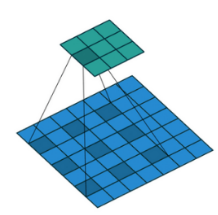

I teraz jeżeli przeszukujemy obszar 5x5 wokół piksela X, to znaczy, że filtr bierze pod uwagę obszar 2 pikseli wokół piksela X, więc dla pikseli granicznych, z racji że nie ma paddingu ucinamy po 2 piksele z każdej strony, lewo prawo góra dół i takim oto sposobem mamy rozmiar 46x46

## Zad 3

pobieramy dataset, będziemy pracować nad zbiorem CIFAR10

In [14]:
from torchvision import datasets

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
  ])

trainset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

c:\Users\RODO\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


 Podstawowe informacje o zbiorze CIFAR-10

In [15]:
# Liczba przykładów
print(f"\n Rozmiar zbiorów:")
print(f"   Zbiór treningowy:  {len(trainset):,} obrazów")
print(f"   Zbiór testowy:     {len(testset):,} obrazów")
print(f"   Razem:             {len(trainset) + len(testset):,} obrazów")

# Kształt danych
sample_image, sample_label = trainset[0]
print(f"\n  Wymiary obrazów:")
print(f"   Kształt tensora:   {tuple(sample_image.shape)} (C, H, W)")


# Klasy
classes = trainset.classes
print(f"\n  Klasy ({len(classes)} kategorii):")
for i, class_name in enumerate(classes):
    print(f"   {i}: {class_name}")

# Rozkład klas w zbiorze treningowym 
print(f"\n Liczba zdjęć w każdej klasie :")
class_counts = {}
for _, label in trainset:
    class_name = classes[label]
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

for class_name in classes:
    count = class_counts.get(class_name, 0)
    print(f"   {class_name:12s}: {count:,} zdjęć")

print(f"\n   RAZEM: {sum(class_counts.values()):,} zdjęć")



 Rozmiar zbiorów:
   Zbiór treningowy:  50,000 obrazów
   Zbiór testowy:     10,000 obrazów
   Razem:             60,000 obrazów

  Wymiary obrazów:
   Kształt tensora:   (3, 32, 32) (C, H, W)

  Klasy (10 kategorii):
   0: airplane
   1: automobile
   2: bird
   3: cat
   4: deer
   5: dog
   6: frog
   7: horse
   8: ship
   9: truck

 Liczba zdjęć w każdej klasie :
   airplane    : 5,000 zdjęć
   automobile  : 5,000 zdjęć
   bird        : 5,000 zdjęć
   cat         : 5,000 zdjęć
   deer        : 5,000 zdjęć
   dog         : 5,000 zdjęć
   frog        : 5,000 zdjęć
   horse       : 5,000 zdjęć
   ship        : 5,000 zdjęć
   truck       : 5,000 zdjęć

   RAZEM: 50,000 zdjęć


Model: Zrobimy model, gdzie będę mógł zmieniać w celu porównania różne metryki

In [16]:
class FlexibleCNN(nn.Module):
    def __init__(self, 
                 input_channels=3, 
                 num_classes=10, 
                 conv_config=None, #  [{'out_channels': 32, 'kernel_size': 3}, ...]
                 pooling_type=None, # 'max' / 'avg'  / None
                 pooling_every_n_layers=1, 
                 use_global_avg_pooling=False,
                 use_batch_norm=False,
                 use_dropout=False,
                 dropout_prob=0.5,
                 image_size=(3, 32, 32) # C, H, W
                 ):
        super().__init__()
        
        # Domyślnie 2 warstwy 
        if conv_config is None:
            conv_config = [
                {'out_channels': 32, 'kernel_size': 3, 'stride': 1, 'padding': 1},
                {'out_channels': 64, 'kernel_size': 3, 'stride': 1, 'padding': 1}
            ]
            
        self.features = nn.Sequential()
        in_c = input_channels
        
        for i, layer_conf in enumerate(conv_config):
            out_c = layer_conf.get('out_channels', 32 * (i + 1))
            k = layer_conf.get('kernel_size', 3)
            s = layer_conf.get('stride', 1)
            p = layer_conf.get('padding', 1)
            d = layer_conf.get('dilation', 1)
            
            #  warstwa konwolucyjna
            self.features.add_module(f'conv_{i}', nn.Conv2d(in_c, out_c, kernel_size=k, stride=s, padding=p, dilation=d))
            
            # Dodanie Batch Norm
            if use_batch_norm:
                self.features.add_module(f'bn_{i}', nn.BatchNorm2d(out_c))
                
            # f. aktywacji
            self.features.add_module(f'relu_{i}', nn.ReLU())
            
            # Dropout
            if use_dropout:
                self.features.add_module(f'dropout_{i}', nn.Dropout2d(p=dropout_prob))
                
            #  Pooling
            if pooling_type and (i + 1) % pooling_every_n_layers == 0:
                if pooling_type == 'max':
                    self.features.add_module(f'pool_{i}', nn.MaxPool2d(kernel_size=2, stride=2))
                elif pooling_type == 'avg':
                    self.features.add_module(f'pool_{i}', nn.AvgPool2d(kernel_size=2, stride=2))
            
            in_c = out_c

        self.use_global_avg_pooling = use_global_avg_pooling
        
        with torch.no_grad():
            dummy_input = torch.zeros(1, *image_size)
            dummy_out = self.features(dummy_input)
            
        if use_global_avg_pooling:
            self.classifier_input = in_c 
        else:
            self.classifier_input = dummy_out.view(1, -1).shape[1]
            
        self.classifier = nn.Sequential(
            nn.Linear(self.classifier_input, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        
        if self.use_global_avg_pooling:
            x = F.adaptive_avg_pool2d(x, (1, 1))
            x = torch.flatten(x, 1)
        else:
            x = torch.flatten(x, 1)
            
        x = self.classifier(x)
        return x
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

Do tego modelu przygotowałem funkcję, która testuje różnice między parametrami i tworzy wykresy, z racji że jest ona dość długa to umieściłem ją w pliku cnn_comparison i tutaj wyświetlę wyniki, które omówię.
Disclaimer: Przy porównywaniu własności nie używam optymalnych cech, więc accuracy (zbiory sa zbalansowane więc acc wydaje się dobrą metryką) nie jest najwyższe. Pod koniec porównywania zbierzemy wszystkie właściwości w celu zrobienia najlepszego wyniku

### 1. Liczba warstw

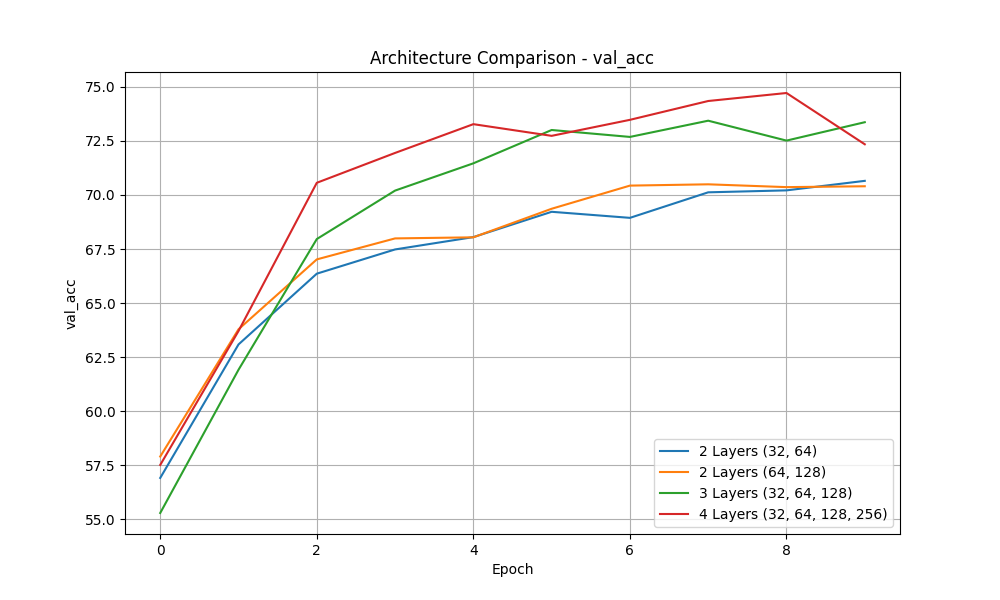

Na początku sieć 3 warstwowa szła w miarę równo, ale wraz z liczbą epok, była w stanie zauważyć więcej detali, przebijając sieci 2 warstwowe. Przy 4 wartstwach jakość się chwieje i zazębia z 3 warstwami więc jest to sygnał że to za dużo jak na ten dataset, zostajemy przy 3 warstwach

### 2. Dylatacja

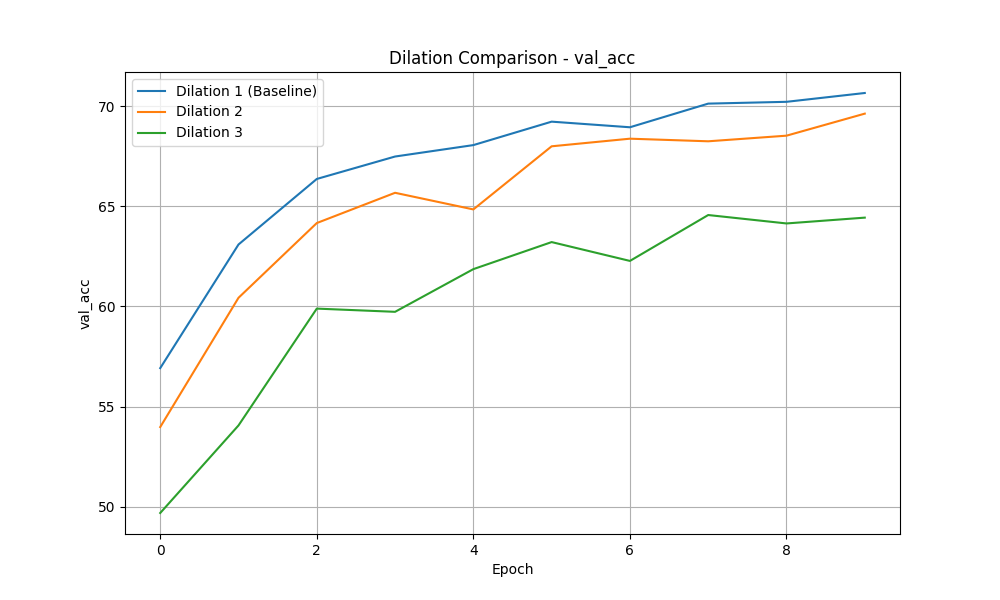

Z racji, że obrazek jest mały (32x32) to dylatacja sprawia że pomijane są sąsiednie piksele, które jak widać są kluczowe do poprawnej klasyfikacji. Zostaje Dilatation o wartości 1

### 3. Rozmiar filtra

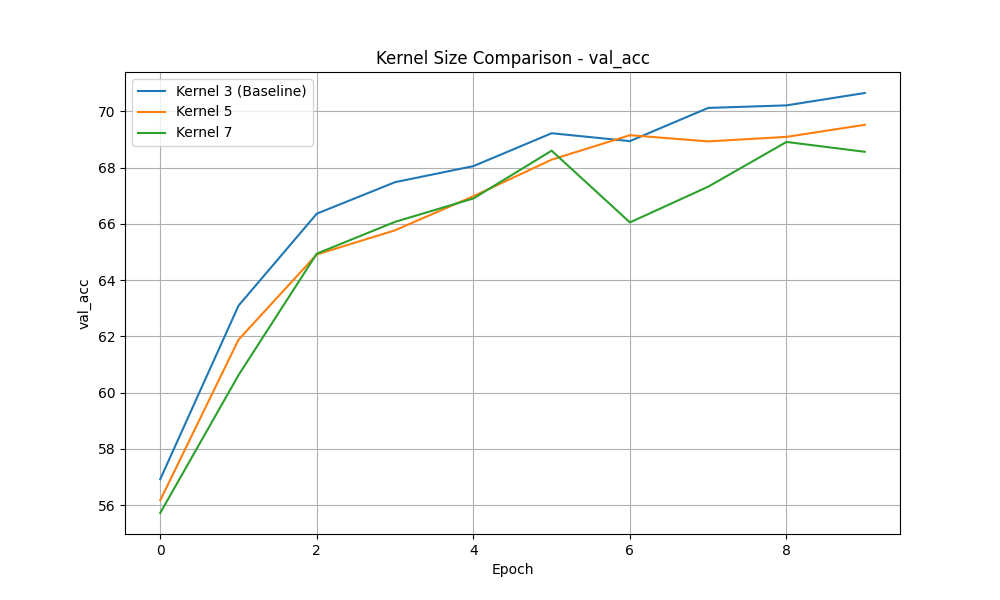

Tutaj pododny wniosek, na tak małych zdjęciach większe kernele patrzą na obraz "zbyt szeroko" nie zauważając tych drobniejszych detali, wiec zostajemy z 3x3

### 4. Stride

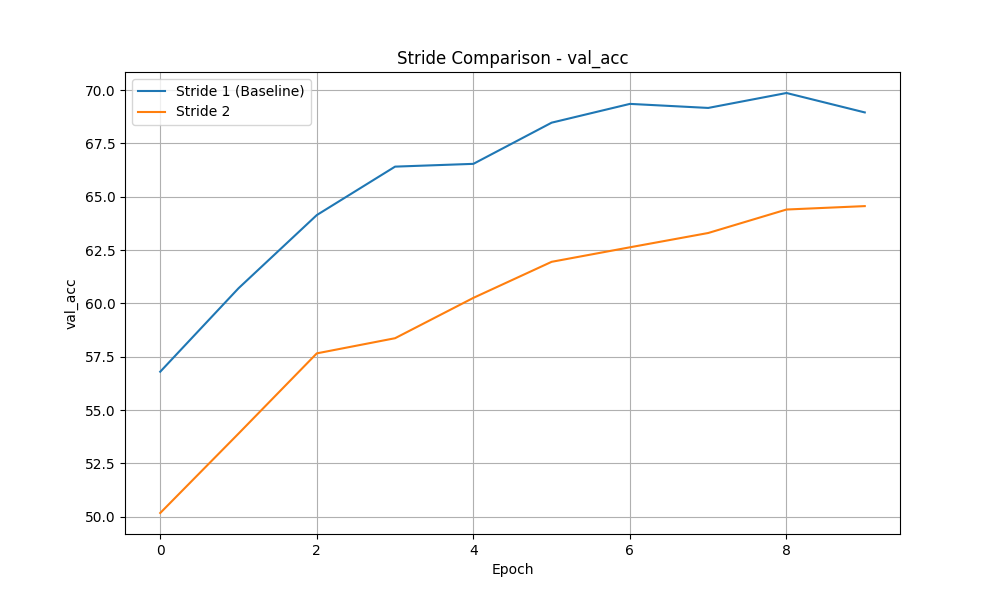

Ten sam wniosek co wyżej, pomijamy za dużo pikseli jak na taki obrazek

### 5. max vs avg pooling

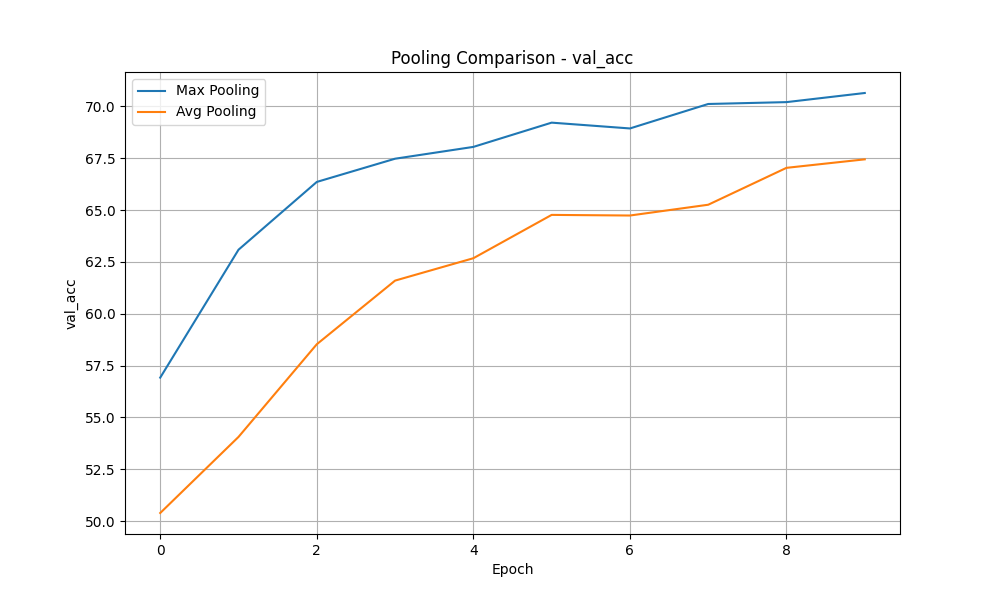

Max pooling bardziej uwydatnia szczegóły, a average romzywa je, skupiając się na tle, więc w miarę logiczne jest to, że max wygrywa

### 6. GAP vs Flatten

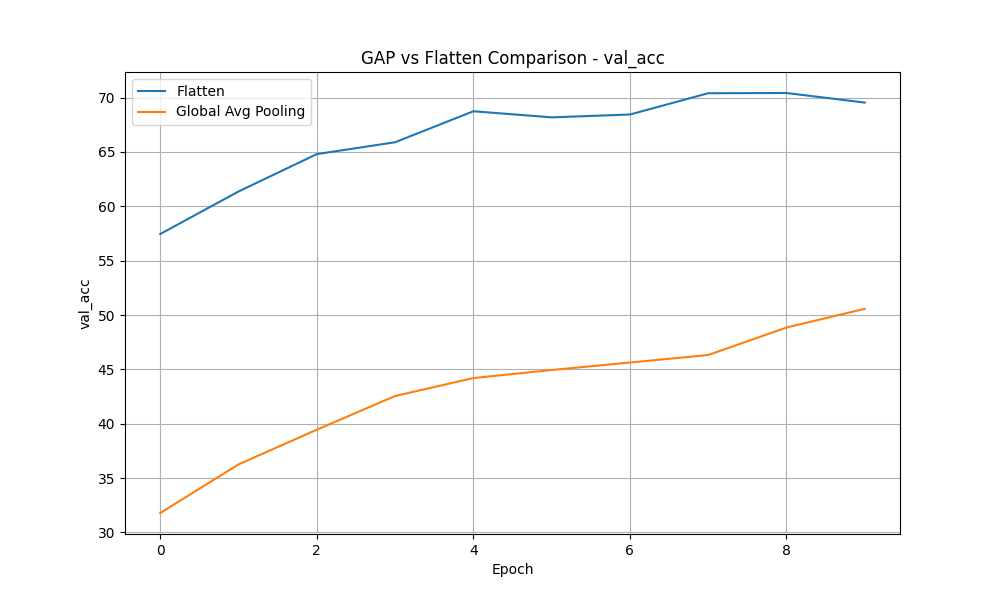

No tutaj funkcja flatten mocno wygrywa z Global average pooling. Dla małej sieci GAP gubi informacje, uśredniając je gdzie flatten je zachowuje

### 7. Dropout i Bnorm

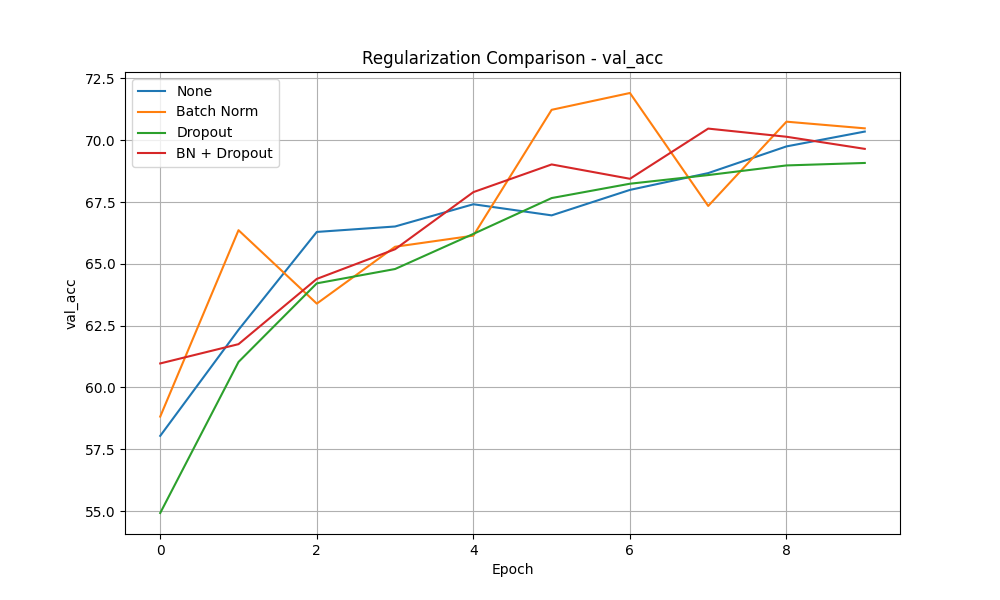
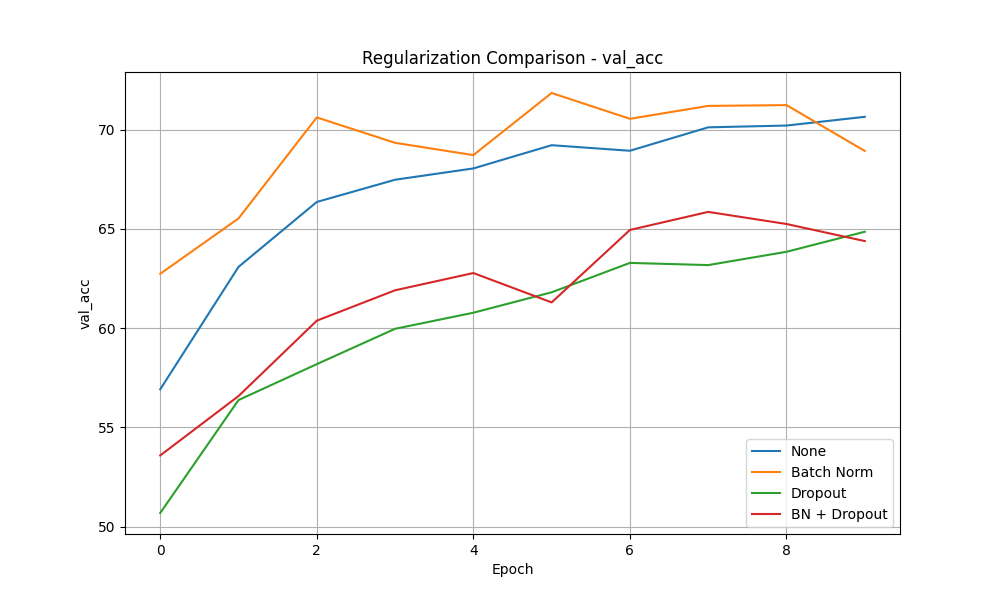

Na tym odcinku wszystko  daje podobne wyniki, nie mniej jednak Bnorm jest mocno chaotyczny, gdzie dropout jest jego przeciwieństwem i wartość acc przy nim rośnie stabilnie, więc myślę (no i na podstawie tego co doczytałem), że użycie połączenia Bnormu z dropoutem będzie git

## Podsumowanie:
- Max pooling
- Kernel 3x3, dilatation = 1, stride = 1
- flatten zamiast gap
- struktura 3 warstwowa
- dodanie dropoutu i Batch normalization

In [20]:
def train_final_model(train_set, test_set, epochs=50, patience=20):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    best_config = {
        'input_channels': 3,
        'num_classes': 10,
        'pooling_type': 'max',
        'use_global_avg_pooling': False,
        'use_batch_norm': True,
        'use_dropout': True,
        'dropout_prob': 0.2,
        'conv_config': [
            {'out_channels': 32, 'kernel_size': 3, 'stride': 1, 'padding': 1},
            {'out_channels': 64, 'kernel_size': 3, 'stride': 1, 'padding': 1},
            {'out_channels': 128, 'kernel_size': 3, 'stride': 1, 'padding': 1}
        ]
    }

    model = FlexibleCNN(**best_config).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=64, shuffle=False)
    
    history = {'loss': [], 'val_acc': []}
    
    best_val_acc = 0.0
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        avg_loss = running_loss / len(train_loader)
        
        # Walidacja
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_acc = 100 * correct / total
        
        history['loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Early Stopping z cierpliwością do 20 epok
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs!")
                break
        
    return model, history


final_model, final_history = train_final_model(trainset, testset, epochs=50)

Epoch 1/50 | Loss: 1.4764 | Val Acc: 61.01%
Epoch 2/50 | Loss: 1.1444 | Val Acc: 65.73%
Epoch 3/50 | Loss: 1.0134 | Val Acc: 71.29%
Epoch 4/50 | Loss: 0.9317 | Val Acc: 71.11%
Epoch 5/50 | Loss: 0.8698 | Val Acc: 73.50%
Epoch 6/50 | Loss: 0.8287 | Val Acc: 74.27%
Epoch 7/50 | Loss: 0.7863 | Val Acc: 74.93%
Epoch 8/50 | Loss: 0.7572 | Val Acc: 75.43%
Epoch 9/50 | Loss: 0.7278 | Val Acc: 76.70%
Epoch 10/50 | Loss: 0.7106 | Val Acc: 76.72%
Epoch 11/50 | Loss: 0.6785 | Val Acc: 76.52%
Epoch 12/50 | Loss: 0.6686 | Val Acc: 77.32%
Epoch 13/50 | Loss: 0.6483 | Val Acc: 77.08%
Epoch 14/50 | Loss: 0.6284 | Val Acc: 77.66%
Epoch 15/50 | Loss: 0.6204 | Val Acc: 77.26%
Epoch 16/50 | Loss: 0.6108 | Val Acc: 77.51%
Epoch 17/50 | Loss: 0.5951 | Val Acc: 77.68%
Epoch 18/50 | Loss: 0.5839 | Val Acc: 78.25%
Epoch 19/50 | Loss: 0.5740 | Val Acc: 78.34%
Epoch 20/50 | Loss: 0.5629 | Val Acc: 77.81%
Epoch 21/50 | Loss: 0.5587 | Val Acc: 77.94%
Epoch 22/50 | Loss: 0.5493 | Val Acc: 78.53%
Epoch 23/50 | Loss:

78/79% to nie najgorszy wynik jak na to że nie augmentowaliśmy danych. Do tego możnaby dołożyć rzeczy takie jak lr scheduling ale tym zajmowaliśmy się listę temu, tu skupiłem się na rzeczach związanych z konwolucjami.